<a href="https://colab.research.google.com/github/musowjanya/Deep-Learning/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader

In [2]:
dataset = datasets.MNIST(root='./data', train=True, download=True,
                         transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.3MB/s]


In [3]:
x_train = dataset.data
y_train = dataset.targets

In [4]:
selected_classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
x_final, y_final = [], []

In [5]:
for cls in selected_classes:
    indices = (y_train == cls).nonzero(as_tuple=True)[0][:100]
    x_final.append(x_train[indices])
    y_final.append(y_train[indices])


In [6]:
xx = torch.cat(x_final)   # (300, 28, 28)
yy = torch.cat(y_final)

In [7]:
xx = xx.float() / 255.0

In [8]:
dataset = TensorDataset(xx, yy)
data = DataLoader(dataset, batch_size=32, shuffle=True)

In [9]:
import torch.nn as nn

class DeepNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28*28, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)   # output layer (10 classes)
        )

    def forward(self, x):
        return self.model(x)

model = DeepNN()

In [10]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
model.train()
for epoch in range(150):
    total_loss = 0

    for xb, yb in data:
        outputs = model(xb)
        loss = loss_fn(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 62.7725
Epoch 2, Loss: 26.6640
Epoch 3, Loss: 14.6566
Epoch 4, Loss: 10.8019
Epoch 5, Loss: 8.6958
Epoch 6, Loss: 6.3990
Epoch 7, Loss: 4.2355
Epoch 8, Loss: 3.1785
Epoch 9, Loss: 2.6665
Epoch 10, Loss: 1.8628
Epoch 11, Loss: 1.5974
Epoch 12, Loss: 1.1651
Epoch 13, Loss: 0.6269
Epoch 14, Loss: 0.4713
Epoch 15, Loss: 0.2971
Epoch 16, Loss: 0.2279
Epoch 17, Loss: 0.1930
Epoch 18, Loss: 0.1517
Epoch 19, Loss: 0.1267
Epoch 20, Loss: 0.1087
Epoch 21, Loss: 0.0940
Epoch 22, Loss: 0.0860
Epoch 23, Loss: 0.0756
Epoch 24, Loss: 0.0701
Epoch 25, Loss: 0.0627
Epoch 26, Loss: 0.0568
Epoch 27, Loss: 0.0523
Epoch 28, Loss: 0.0479
Epoch 29, Loss: 0.0437
Epoch 30, Loss: 0.0392
Epoch 31, Loss: 0.0373
Epoch 32, Loss: 0.0355
Epoch 33, Loss: 0.0316
Epoch 34, Loss: 0.0298
Epoch 35, Loss: 0.0286
Epoch 36, Loss: 0.0260
Epoch 37, Loss: 0.0241
Epoch 38, Loss: 0.0231
Epoch 39, Loss: 0.0216
Epoch 40, Loss: 0.0207
Epoch 41, Loss: 0.0188
Epoch 42, Loss: 0.0178
Epoch 43, Loss: 0.0175
Epoch 44, Loss: 

In [12]:
# model(x_train)

In [13]:
import cv2

In [16]:
ar=cv2.imread('/content/five.jpg')

In [17]:
ar.shape

(272, 210, 3)

In [18]:
grar=cv2.cvtColor(ar,cv2.COLOR_BGR2GRAY)

In [19]:
rszar=cv2.resize(grar,(28,28))

In [20]:
far=rszar.reshape(1,1,28,28)

In [21]:
far

array([[[[255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          255, 255, 255, 255],
         [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          255, 255, 255, 255],
         [255, 255, 255, 255, 255, 250, 254, 254, 254, 254, 254, 254,
          254, 254, 254, 254, 254, 254, 254, 255, 243,   0,   0, 216,
          255, 255, 255, 255],
         [255, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 216,
          255, 255, 255, 255],
         [255, 255, 255, 255, 255, 254,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 216,
          255, 255, 255, 255],
         [255, 255, 255, 255, 255, 254,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 216,
     

In [22]:
import matplotlib.pyplot as plt

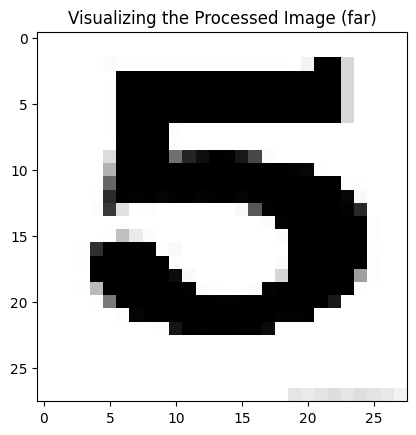

In [23]:
plt.imshow(far.squeeze(), cmap='gray')
plt.title('Visualizing the Processed Image (far)')
plt.show()

In [24]:
fimg = torch.from_numpy(far).float()
print(f"Shape of fimg before model call: {fimg.shape}")

Shape of fimg before model call: torch.Size([1, 1, 28, 28])


In [25]:
model(fimg)

tensor([[ -9351.7715,  -7373.5884,   -866.0095,   8286.1445, -11918.7393,
          -5913.3418, -21633.2930,   4110.3965,  -3839.7776,   3509.7666]],
       grad_fn=<AddmmBackward0>)

In [26]:
sfx=torch.softmax(model(fimg),dim=1)

In [28]:
torch.argmax(sfx,dim=1)

tensor([3])